In [1]:
# 简单地说，机器学习就是做出预测。

'''根据病人的临床病史，我们可能想预测他们在下一年心脏病发作的概率。 在飞机喷气发动机的异常检测中，我们想要评估一组发动机读数为正常运行情况的概率有多大。 
在强化学习中，我们希望智能体（agent）能在一个环境中智能地行动。 这意味着我们需要考虑在每种可行的行为下获得高奖励的概率。 当我们建立推荐系统时，我们也需要考虑概率。 例如，假设我们为一家大型在线书店工作，我们可能希望估计某些用户购买特定图书的概率。 为此，我们需要使用概率学。 有完整的课程、专业、论文、职业、甚至院系，都致力于概率学的工作。 
所以很自然地，我们在这部分的目标不是教授整个科目。 相反，我们希望教给读者基础的概率知识，使读者能够开始构建第一个深度学习模型， 以便读者可以开始自己探索它。'''

'根据病人的临床病史，我们可能想预测他们在下一年心脏病发作的概率。 在飞机喷气发动机的异常检测中，我们想要评估一组发动机读数为正常运行情况的概率有多大。 \n在强化学习中，我们希望智能体（agent）能在一个环境中智能地行动。 这意味着我们需要考虑在每种可行的行为下获得高奖励的概率。 当我们建立推荐系统时，我们也需要考虑概率。 例如，假设我们为一家大型在线书店工作，我们可能希望估计某些用户购买特定图书的概率。 为此，我们需要使用概率学。 有完整的课程、专业、论文、职业、甚至院系，都致力于概率学的工作。 \n所以很自然地，我们在这部分的目标不是教授整个科目。 相反，我们希望教给读者基础的概率知识，使读者能够开始构建第一个深度学习模型， 以便读者可以开始自己探索它。'

In [4]:
%matplotlib inline
import torch
from torch.distributions import multinomial
from d2l import torch as d2l

In [5]:
# 在统计学中，我们把从概率分布中抽取样本的过程称为抽样（sampling）。 笼统来说，可以把分布（distribution）看作对事件的概率分配， 稍后我们将给出的更正式定义。 将概率分配给一些离散选择的分布称为多项分布（multinomial distribution）。
fair_probs = torch.ones([6]) / 6
# torch.ones([6])：创建一个长度为 6 的张量，每个元素都是 1
# / 6：把每个元素都除以 6，得到 [1/6, 1/6, 1/6, 1/6, 1/6, 1/6]
# 这表示一个公平六面骰子的概率分布


multinomial.Multinomial(1, fair_probs).sample() 
# Multinomial(1, fair_probs)：表示“根据这个概率分布，抽 1 次”
# .sample()：真正执行一次抽样


tensor([0., 0., 1., 0., 0., 0.])

In [6]:
multinomial.Multinomial(10, fair_probs).sample()

tensor([0., 4., 1., 3., 1., 1.])

In [11]:
# 将结果存储为32位浮点数以进行除法
n= 5000
counts = multinomial.Multinomial(n, fair_probs).sample()
counts / n  # 相对频率作为估计值

tensor([0.1670, 0.1700, 0.1596, 0.1676, 0.1638, 0.1720])

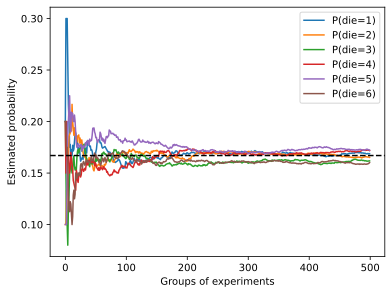

In [12]:
counts = multinomial.Multinomial(10, fair_probs).sample((500,))
cum_counts = counts.cumsum(dim=0)
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)

d2l.set_figsize((6, 4.5))
for i in range(6):
    d2l.plt.plot(estimates[:, i].numpy(),
                 label=("P(die=" + str(i + 1) + ")"))
d2l.plt.axhline(y=0.167, color='black', linestyle='dashed')
d2l.plt.gca().set_xlabel('Groups of experiments')
d2l.plt.gca().set_ylabel('Estimated probability')
d2l.plt.legend();